In [3]:
!pip install seaborn scikit-learn matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import pickle, json





In [4]:
from google.colab import files
uploaded = files.upload()

Saving website_performance.csv to website_performance.csv


In [5]:

import io
df = pd.read_csv(io.BytesIO(uploaded['website_performance.csv']))
print("✅ Dataset loaded successfully!")
print("Shape of dataset:", df.shape)
df.head()

✅ Dataset loaded successfully!
Shape of dataset: (346174, 17)


,traffic_source,dates,hours,users,sessions,engaged_sessions,avg_engagement_time_per_session,engaged_sessions_per_user,events_per_session,engagement_rate,event_count,page_views,session_duration,bounce_rate,time_on_page,previous_visits,conversion_rate
0,Direct,2024-05-29 00:00:00,4,11,17,6,00:00:59.352941,0.55,3.88,0.35,66,2,2.773784,0.485768,2.973653,3,1.0
1,Direct,2024-05-28 00:00:00,6,11,15,5,00:00:05.466667,0.45,2.67,0.33,40,2,2.773784,0.485768,2.973653,3,1.0
2,Direct,2024-09-27 00:00:00,5,11,16,2,00:00:09.625,0.18,3.13,0.13,50,2,2.773784,0.485768,2.973653,3,1.0
3,Direct,2024-05-16 00:00:00,3,11,18,6,00:00:05.833333,0.55,3.06,0.33,55,2,2.773784,0.485768,2.973653,3,1.0
4,Direct,2024-02-08 00:00:00,2,11,18,3,00:00:20.222222,0.27,3.11,0.17,56,2,2.773784,0.485768,2.973653,3,1.0


In [6]:
# ======================================
# STEP 3️⃣ : DATA EXPLORATION
# ======================================

print("\n🔍 Checking missing values:")
print(df.isnull().sum())

print("\n📊 Basic statistical summary:")
print(df.describe())

print("\n🧾 Columns in dataset:")
print(df.columns)


🔍 Checking missing values:
traffic_source                     0
dates                              0
hours                              0
users                              0
sessions                           0
engaged_sessions                   0
avg_engagement_time_per_session    0
engaged_sessions_per_user          0
events_per_session                 0
engagement_rate                    0
event_count                        0
page_views                         0
session_duration                   0
bounce_rate                        0
time_on_page                       0
previous_visits                    0
conversion_rate                    0
dtype: int64

📊 Basic statistical summary:
               hours          users       sessions  engaged_sessions  \
count  346174.000000  346174.000000  346174.000000     346174.000000   
mean       11.494318      41.884754      49.991244         28.636602   
std         6.916751      19.476809      22.740395         13.964122   
min         

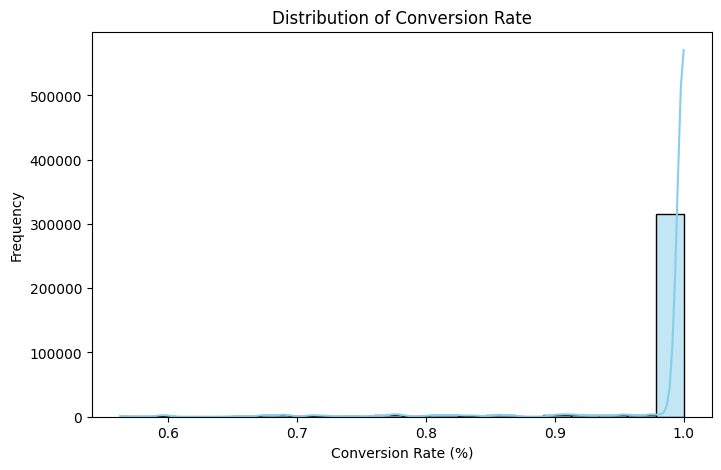

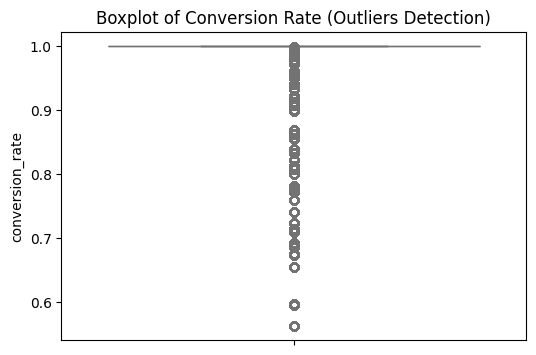

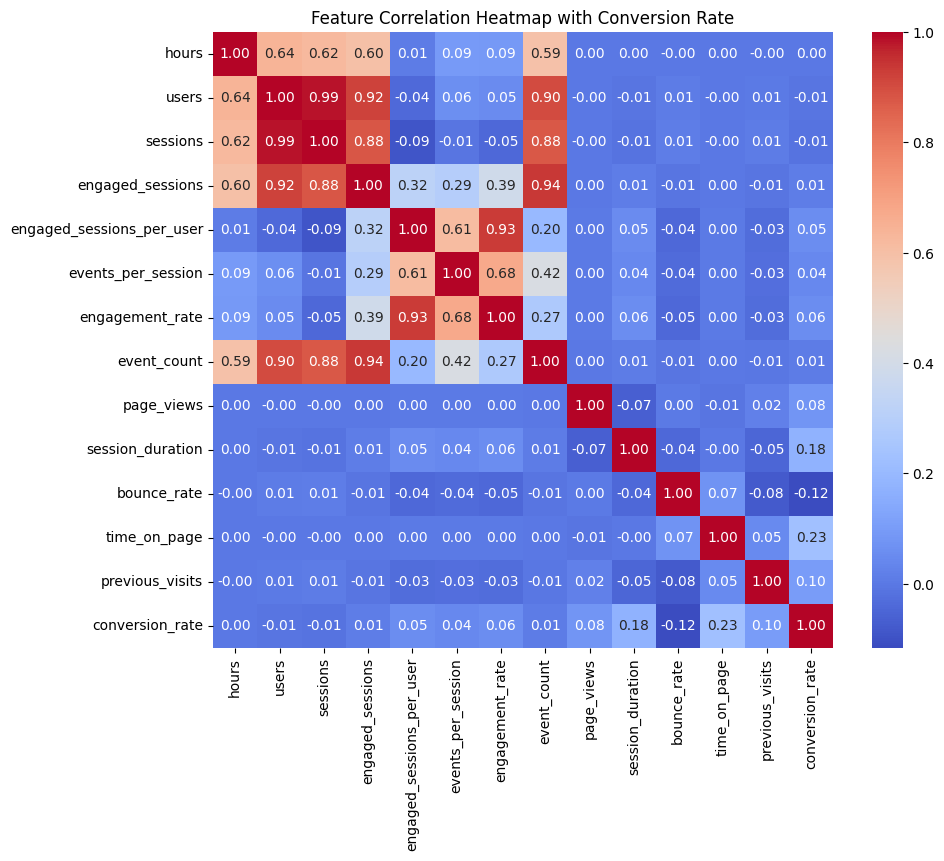

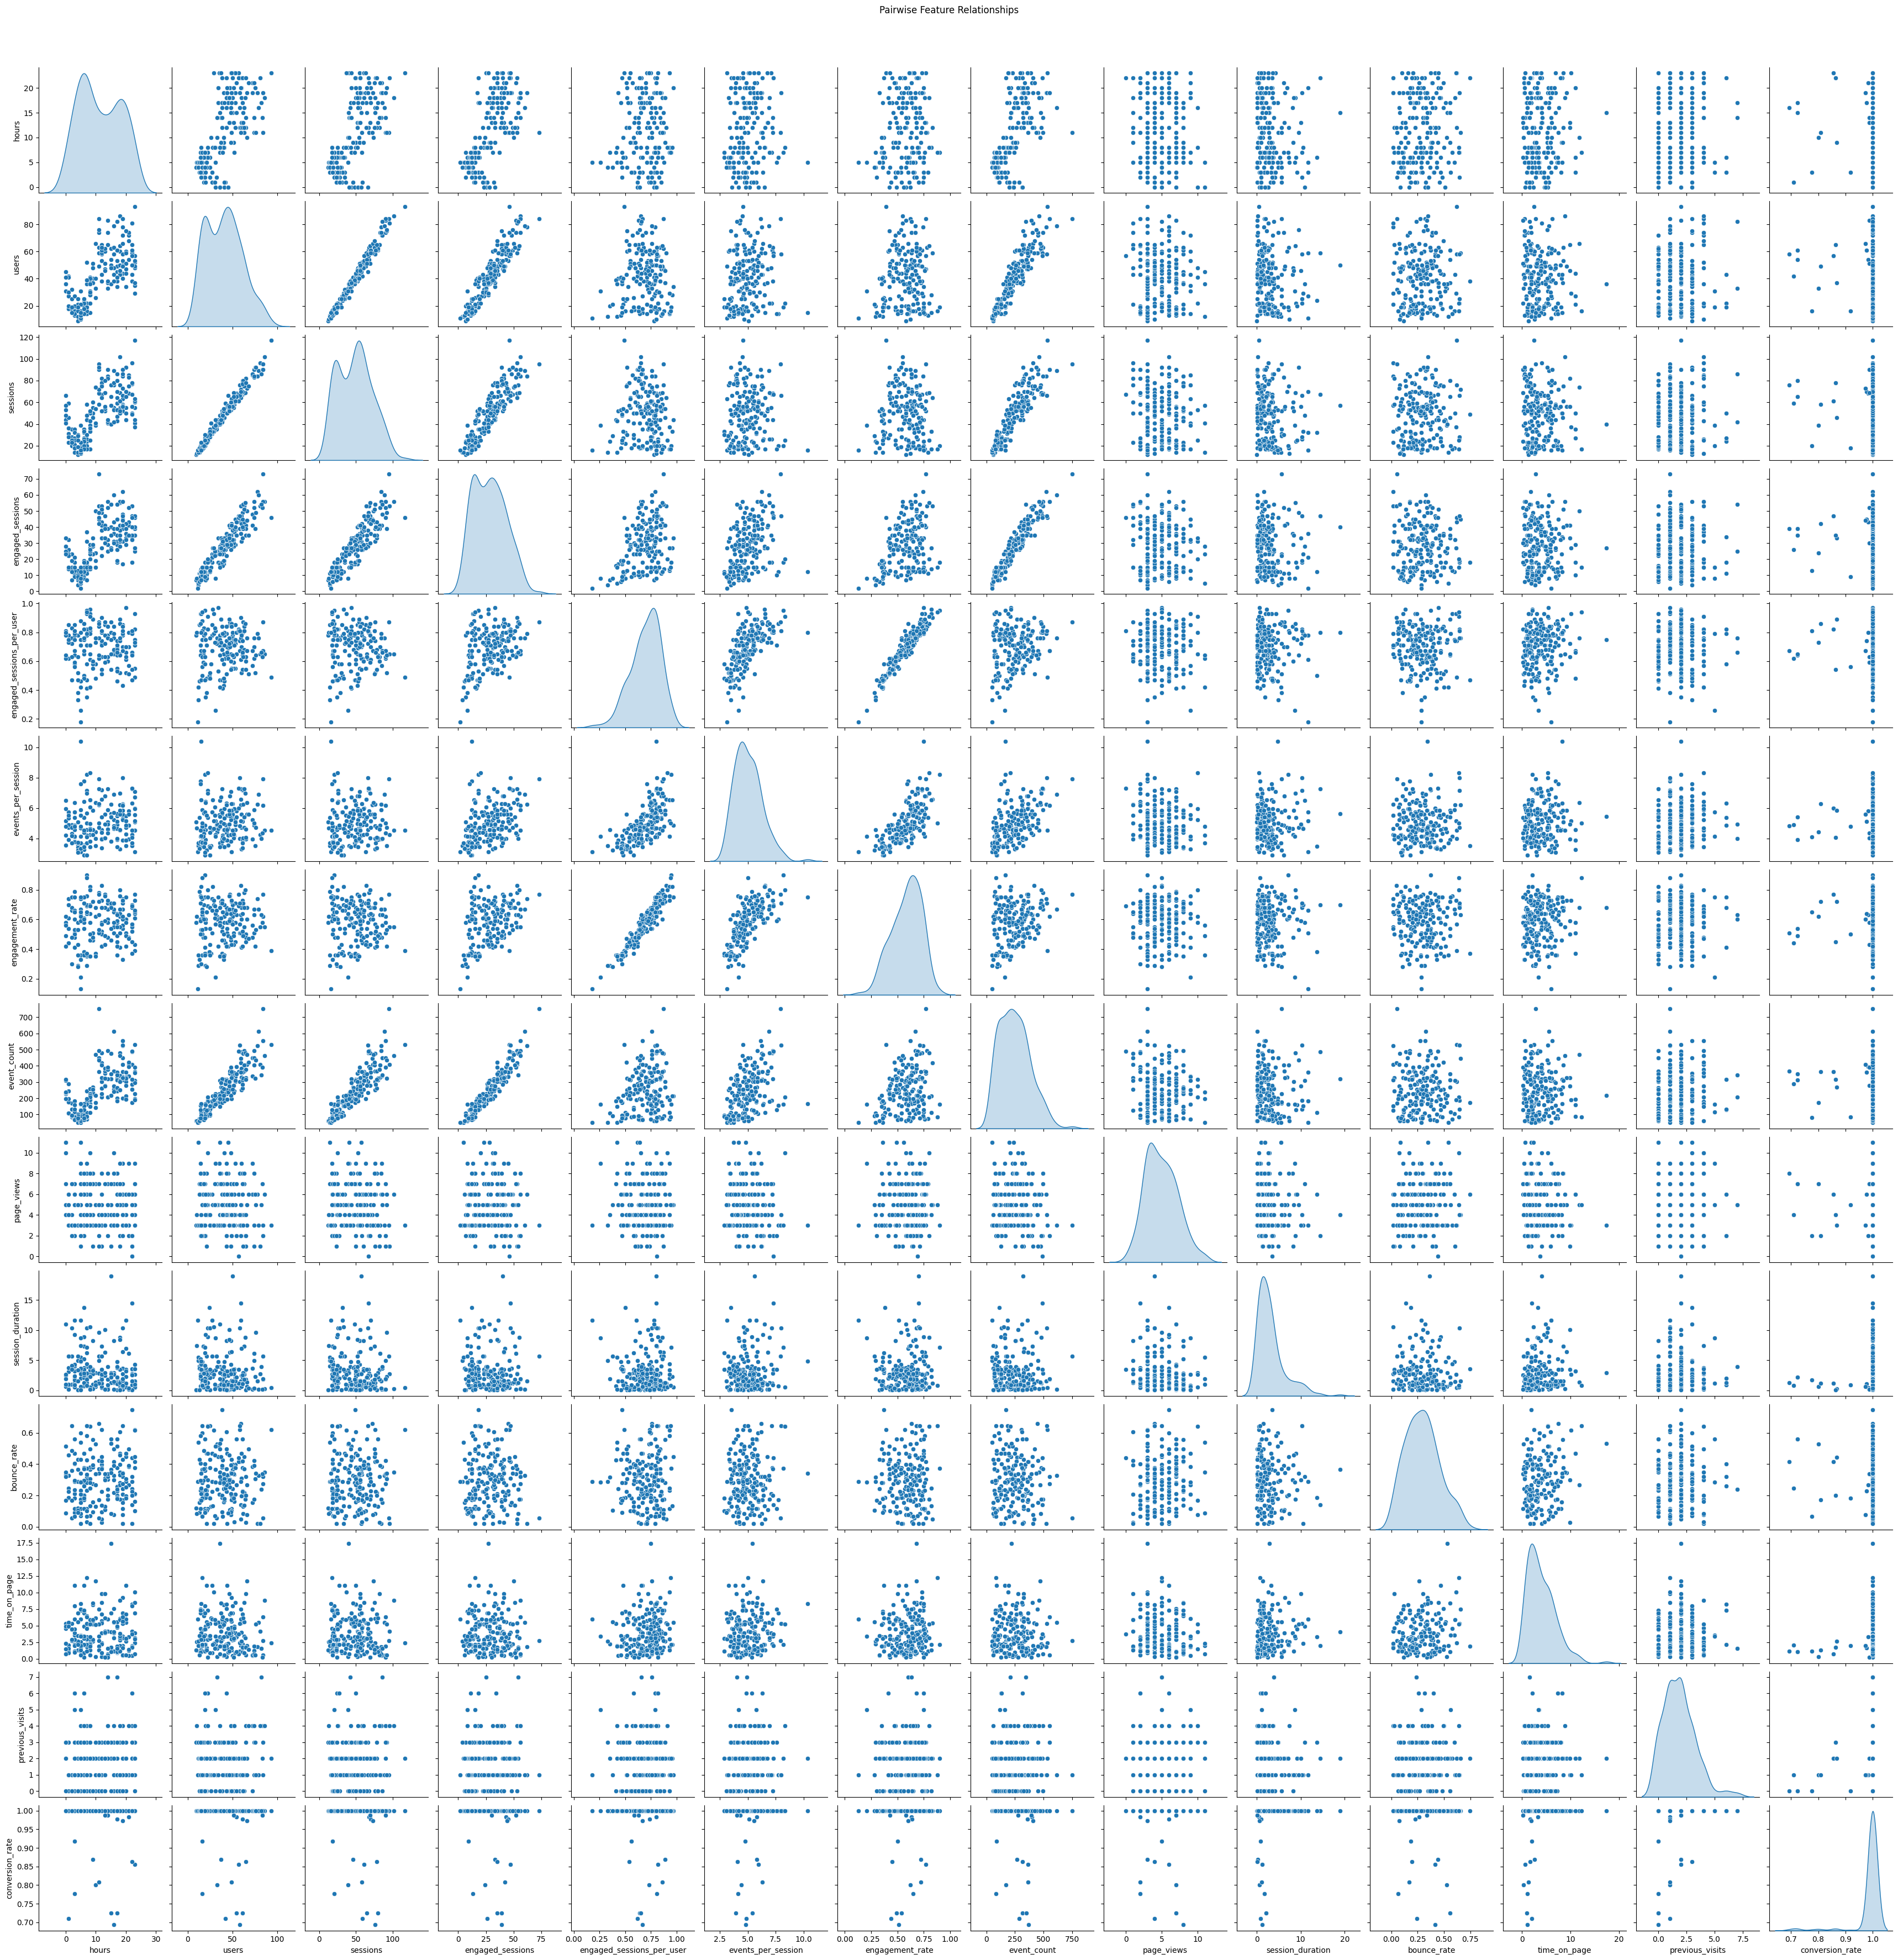

In [8]:
# ======================================
# STEP 4️⃣ : DATA VISUALIZATION (EDA)
# ======================================

# --- Histogram for conversion_rate ---
plt.figure(figsize=(8,5))
sns.histplot(df['conversion_rate'], kde=True, color='skyblue')
plt.title("Distribution of Conversion Rate")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Frequency")
plt.show()

# --- Boxplot to check for outliers ---
plt.figure(figsize=(6,4))
sns.boxplot(y=df['conversion_rate'], color='lightgreen')
plt.title("Boxplot of Conversion Rate (Outliers Detection)")
plt.show()

# --- Correlation Heatmap ---
# Use only numeric columns (ignore text ones like 'traffic_source')
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap with Conversion Rate")
plt.show()

# --- Pairplot for relationship visualization (optional) ---
# Only for numeric columns to avoid errors
sns.pairplot(numeric_df.sample(min(200, len(numeric_df))), diag_kind='kde')
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()


In [9]:
# ======================================
# STEP 5️⃣ : DEFINE FEATURES & TARGET
# ======================================

feature_cols = [
    'hours','users','sessions','engaged_sessions','engaged_sessions_per_user',
    'events_per_session','event_count','page_views','session_duration',
    'bounce_rate','time_on_page','previous_visits'
]

X = df[feature_cols]
y = df['conversion_rate']

print("✅ Feature matrix (X) and target (y) prepared!")
print("X shape:", X.shape)
print("y shape:", y.shape)


✅ Feature matrix (X) and target (y) prepared!
X shape: (346174, 12)
y shape: (346174,)


In [10]:
# ======================================
# STEP 6️⃣ : TRAIN-TEST SPLIT
# ======================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (276939, 12)
Testing set: (69235, 12)


In [11]:
# ======================================
# STEP 7️⃣ : BUILD & TRAIN MODEL
# ======================================
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", GradientBoostingRegressor(random_state=42))
])

pipeline.fit(X_train, y_train)
print("✅ Model trained successfully!")


✅ Model trained successfully!



📈 Model Evaluation Results:
Mean Squared Error (MSE): 0.000305
R² Score: 0.9177


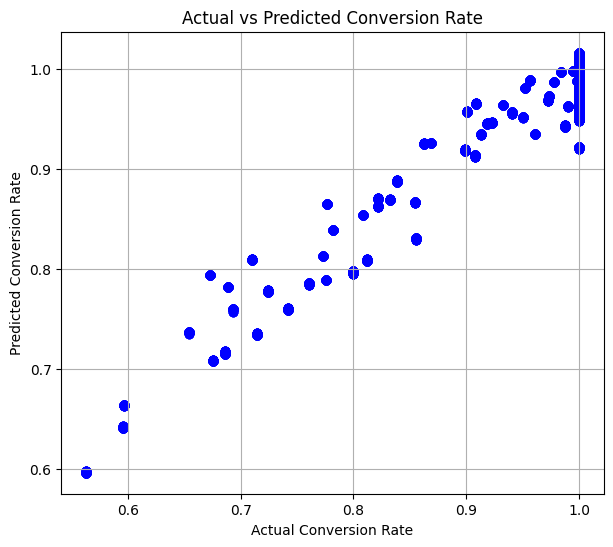

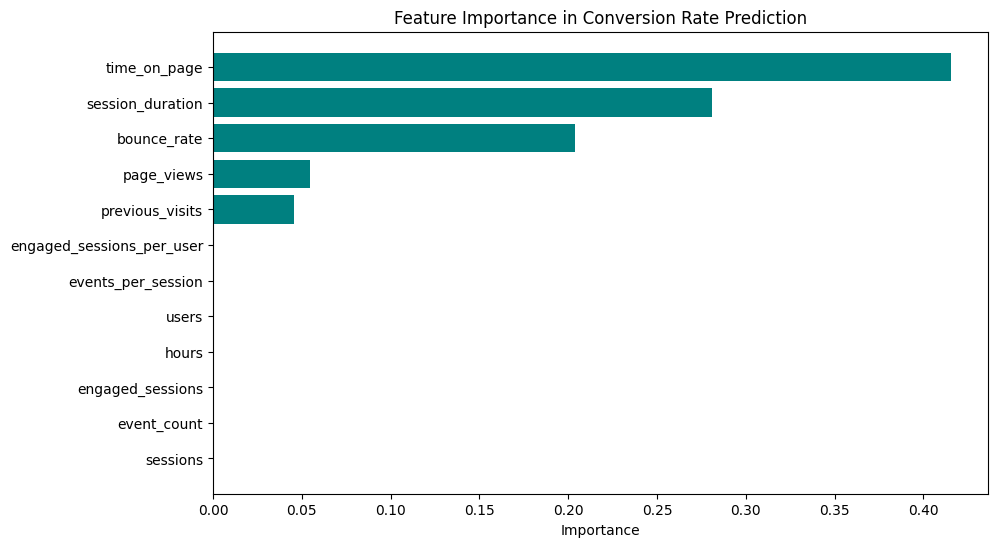

In [12]:
# ======================================
# STEP 8️⃣ : EVALUATE MODEL
# ======================================
y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📈 Model Evaluation Results:")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"R² Score: {r2:.4f}")

# --- Scatter Plot for Actual vs Predicted ---
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.xlabel("Actual Conversion Rate")
plt.ylabel("Predicted Conversion Rate")
plt.title("Actual vs Predicted Conversion Rate")
plt.grid(True)
plt.show()

# --- Feature Importance Plot ---
model = pipeline.named_steps['regressor']
importances = model.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx], color='teal')
plt.title("Feature Importance in Conversion Rate Prediction")
plt.xlabel("Importance")
plt.show()

In [13]:
# ======================================
# STEP 9️⃣ : SAVE TRAINED MODEL
# ======================================
pickle.dump(pipeline, open("model.pkl", "wb"))
print("💾 Model saved as model.pkl")

💾 Model saved as model.pkl


In [14]:
# ======================================
# STEP 🔟 : SAVE FEATURE MEANS
# ======================================
feature_means = X.mean().to_dict()
with open("feature_means.json", "w") as f:
    json.dump(feature_means, f)
print("💾 Feature means saved to feature_means.json")

💾 Feature means saved to feature_means.json


In [15]:
# ======================================
# ✅ STEP 11️⃣ : DOWNLOAD OUTPUT FILES
# ======================================
from google.colab import files
files.download("model.pkl")
files.download("feature_means.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>